<a href="https://colab.research.google.com/github/7oo4/datascience_regression/blob/main/Hoor_Alabkash_MA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color = blue size = 6> **Midterm Alternative (10 marks)**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/7oo4/datascience_regression/blob/main/Hoor_Alabkash_MA.ipynb)

# Overview:

In this homework for the midterm alternative, you will use the famous Iris dataset to explore linear regression using Python's datascience library. You will load real data, visualize relationships between variables, fit a regression line, and interpret the results.



# Learning Objectives:

- Load and explore a public dataset using the datascience Table class
- Create scatter plots with regression lines
- Calculate and interpret slope, intercept, and correlation coefficient
- Make predictions using a regression equation
- Analyze residuals to evaluate model fit


# Dataset Description
The Iris dataset is one of the most well-known datasets in data science. It contains measurements of 150 iris flowers across 3 species: setosa, versicolor, and virginica.

You can download or open Iris dataset using https://www.kaggle.com/datasets/uciml/iris .


## Setup Instructions [0 marks]

import necessary libraries

In [24]:
!pip install datascience
from datascience import *
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

In [25]:
from datascience import *
%matplotlib inline
#path_data = '../../../assets/data/'
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import numpy as np

Load data to a table (Use the following cell to load dataset.)

In [26]:
# load dataset:
iris = Table.read_table('Iris.csv')

# Tasks

- Use the given cells to provide your Python code.
- If the question asks for an explanation, use comment lines ('#') to provide your explanation after the code.

## <font color = blue size  = 5>**Task 1: Data Exploration (1 Mark)**

**Task Description:**

- Answer the following questions by providing appropriate Python codes


In [27]:
# (1) how many rows and columns does the dataset have? print the column names.

# print the total number of rows and columns in the dataset:
print('Number of rows:', iris.num_rows)
print('Number of columns:', iris.num_columns)

# print all column names:
print('Column names:', iris.labels)

Number of rows: 150
Number of columns: 6
Column names: ('Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species')


In [28]:
# (2) how many flowers are there per species? use the .group() method.

# group the data by species and count how many flowers are in each group
iris.group('Species')

Species,count
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [29]:
# (3) calculate the mean, minimum, and maximum of petal_length and petal_width using numpy.

# extract petal length and width columns as arrays:
petal_length = iris.column('PetalLengthCm')
petal_width = iris.column('PetalWidthCm')

# calculate and display statistics for both columns:
print('Petal Length - Mean:', np.mean(petal_length), ', Min:', np.min(petal_length), ', Max:', np.max(petal_length))
print('Petal Width  - Mean:', np.mean(petal_width), ', Min:', np.min(petal_width), ', Max:', np.max(petal_width))

Petal Length - Mean: 3.75866666667 , Min: 1.0 , Max: 6.9
Petal Width  - Mean: 1.19866666667 , Min: 0.1 , Max: 2.5


## <font color = blue size  = 5> **Task 2: Visualization (2 Marks)**


**Task Description:**
- Answer the following questions by providing appropriate Python codes

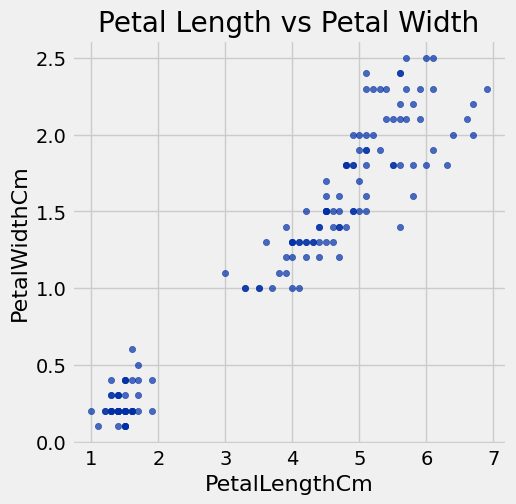

In [30]:
# (4) create a scatter plot with petal_length on the x-axis and petal_width on the y-axis.

# create a scatter plot to visualize the relationship between petal length and width:
iris.scatter('PetalLengthCm', 'PetalWidthCm')
plt.title('Petal Length vs Petal Width')
plt.show()

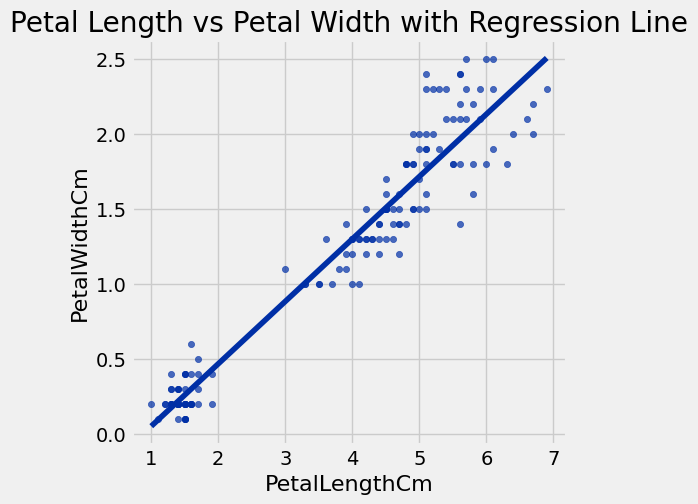

In [31]:
# (5) add a regression line to the scatter plot using fit_line=True.

# create scatter plot with a best-fit regression line to show the trend:
iris.scatter('PetalLengthCm', 'PetalWidthCm', fit_line=True)
plt.title('Petal Length vs Petal Width with Regression Line')
plt.show()

# the scatter plot shows a strong positive linear relationship between petal length (x) and width (y).
# as petal length increases petal width also increases, and the regression line fits the data closely.

## <font color = blue size  = 5> **Task 3: Linear Regression (3 Marks)**

**Task Description:**
- Use the following helper functions in your notebook to compute the regression line
- Then answer the questions

In [32]:
def standard_units(arr):
    return (arr - np.mean(arr)) / np.std(arr)


In [33]:
def correlation(t, x, y):
    return np.mean(standard_units(t.column(x)) * standard_units(t.column(y)))


In [34]:
def slope(t, x, y):
    r = correlation(t, x, y)
    return r * np.std(t.column(y)) / np.std(t.column(x))


In [35]:
def intercept(t, x, y):
    return np.mean(t.column(y)) - slope(t, x, y) * np.mean(t.column(x))


In [36]:
# (6) compute and print the slope and intercept of the regression line.

# calculate slope and intercept using the helper functions:
m = slope(iris, 'PetalLengthCm', 'PetalWidthCm')
b = intercept(iris, 'PetalLengthCm', 'PetalWidthCm')

# display the slope and intercept values:
print('Slope:', m)
print('Intercept:', b)

# print the full regression equation:
print('Regression equation: petal_width =', round(m, 4), '* petal_length +', round(b, 4))

Slope: 0.416419132285
Intercept: -0.366514045217
Regression equation: petal_width = 0.4164 * petal_length + -0.3665


In [37]:
# (7) predict the petal width of a flower with petal_length = 4.5 cm.

# use the regression equation: petal_width = slope * petal_length + intercept:
predicted = m * 4.5 + b

# display the predicted value:
print('Predicted petal width for petal_length = 4.5 cm:', predicted)

Predicted petal width for petal_length = 4.5 cm: 1.50737205007


In [38]:
# (8) compute the correlation coefficient r between petal_length and petal_width.

# calculate r using the correlation helper function:
r = correlation(iris, 'PetalLengthCm', 'PetalWidthCm')

# display the correlation coefficient:
print('Correlation coefficient r:', r)

# the correlation coefficient r is approximately 0.96 which is very close to 1.
# this indicates a strong positive linear relationship between petal length and petal width.
# as petal length increases, petal width consistently increases as well.

Correlation coefficient r: 0.962757097051


## <font color = blue size  = 5> **Task 4: Residual Analysis (4 Marks)**


- Use the regression line you calculated in the following questions.

In [39]:
# (9) compute predicted petal_width and residuals, add them as new columns.

# calculate predicted petal width for every flower using the regression equation:
predicted_vals = m * iris.column('PetalLengthCm') + b

# calculate residuals (actual - predicted):
residuals = iris.column('PetalWidthCm') - predicted_vals

# add predicted values and residuals as new columns to the table:
iris_with_residuals = iris.with_columns(
    'Predicted PetalWidth', predicted_vals,
    'Residuals', residuals
)

# display the first 8 rows:
iris_with_residuals.show(8)

Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,Predicted PetalWidth,Residuals
1,5.1,3.5,1.4,0.2,Iris-setosa,0.216473,-0.0164727
2,4.9,3,1.4,0.2,Iris-setosa,0.216473,-0.0164727
3,4.7,3.2,1.3,0.2,Iris-setosa,0.174831,0.0251692
4,4.6,3.1,1.5,0.2,Iris-setosa,0.258115,-0.0581147
5,5,3.6,1.4,0.2,Iris-setosa,0.216473,-0.0164727
6,5.4,3.9,1.7,0.4,Iris-setosa,0.341398,0.0586015
7,4.6,3.4,1.4,0.3,Iris-setosa,0.216473,0.0835273
8,5,3.4,1.5,0.2,Iris-setosa,0.258115,-0.0581147


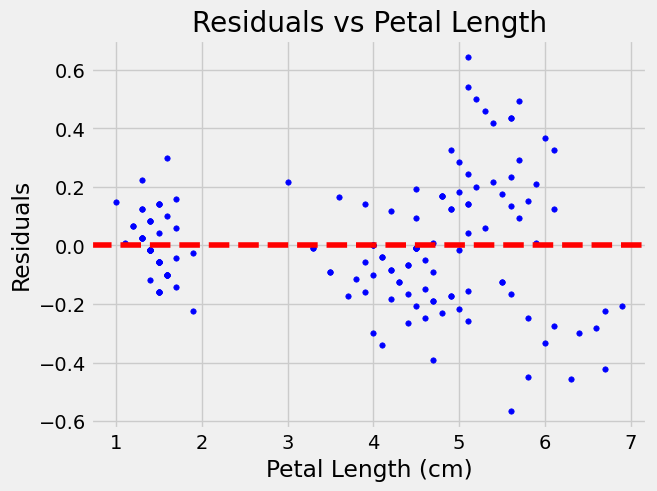

In [40]:
# (10) create a scatter plot of residuals vs petal_length with a horizontal line at y = 0.

# plot residuals against petal length to check model fit:
plt.scatter(iris_with_residuals.column('PetalLengthCm'), iris_with_residuals.column('Residuals'), color='blue', s=15)

# add a red dashed horizontal line at y = 0 for reference:
plt.axhline(y=0, color='red', linestyle='--')

# add labels and title:
plt.xlabel('Petal Length (cm)')
plt.ylabel('Residuals')
plt.title('Residuals vs Petal Length')
plt.show()

# the residuals are mostly scattered around the zero line meaning the model fits reasonably well.
# but there is some clustering for smaller petal lengths and a slight curved pattern,
# which suggests the linear model may not perfectly capture the differences between species.

# Submission Guidelines

- Make sure all cells have been run and outputs are visible before submitting.
- Name your file: FirstName_LastName_MA.ipynb
- Add a "Open in Colab" button at the top of your notebook using the following Markdown code:
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/your-repo-path/notebook.ipynb)

- Upload your completed Jupyter Notebook to a GitHub repository.
- Submit the link to your GitHub repository in the Blackboard along with the Jupyter solution file.
- <font color = red size = 6> ATTENTION!!! </font> This is an individual assessment. Students should not work on groups and the submission should be individual.  

# Grading Rubric
based on the following criteria:

- Correctness : The solution produces the expected output using the Table abstraction .
- Clarity : Code is well-organized, readable, and includes comments explaining key steps.
- Creativity : Visualizations and analyses are presented in an engaging and insightful manner.

# Hints for Success
- Use the Table abstraction methods like .select(), .where(), .group(), .apply(), and .sample() for data manipulation.
- Refer to the slides for the regression.
- Test your code frequently to ensure it runs without errors.